In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from textwrap import fill

def _fmt_num(v):
    if isinstance(v, (bool, np.bool_)):
        return str(bool(v)).lower()
    try:
        fv = float(v)
        return str(int(fv)) if fv.is_integer() else f"{fv:.2f}"
    except Exception:
        return str(v)

def _format_mode(col, mode_value):
    if col in ("upload_size", "download_size"):
        value = float(mode_value) / 1024.0
        unit = "KB"
    elif col == "bandwidth":
        value = mode_value
        unit = "Mbps"
    elif col == "latency":
        value = mode_value
        unit = "ms"
    else:
        value = mode_value
        unit = ""
    return f"{col}={_fmt_num(value)}{unit}"

def build_fixed_note(df_native, df_browser, varying_cols):
    merged = pd.concat([df_native, df_browser], ignore_index=True)
    ordered_cols = ["latency", "bandwidth", "upload_size", "download_size"]
    parts = []
    for col in ordered_cols:
        if col in merged.columns and col not in varying_cols:
            s = merged[col].dropna()
            if not s.empty:
                mode_value = s.mode().iloc[0]
                parts.append(_format_mode(col, mode_value))
    note = "Fixed variables (mode): " + "; ".join(parts)
    return fill(note, width=140)

def add_fixed_note(fig, note_text):
    # Place fixed variables as a subtitle under the chart
    fig.text(0.5, 0.035, note_text, ha="center", va="bottom", fontsize=10, style="italic")


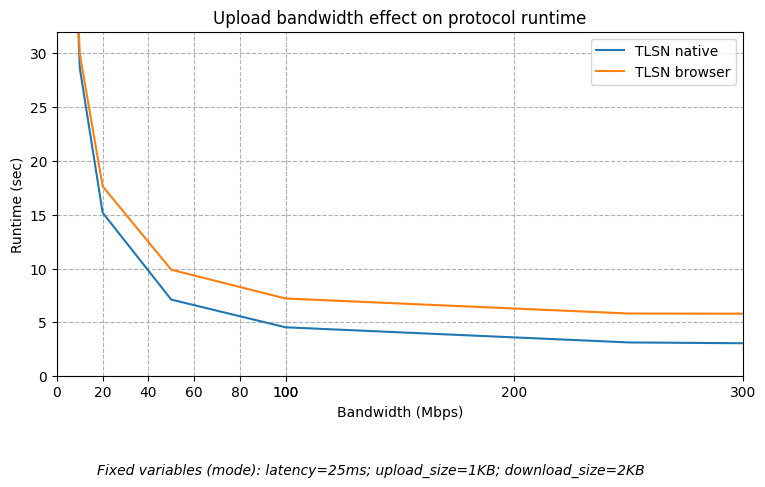

In [42]:
plt.style.use("default")

fig, ax = plt.subplots(figsize=(8, 5))

df1 = pd.read_csv("tlsn-experiments/tlsn-bandwidth-native.csv", header=0).dropna(subset=["group"])
df2 = pd.read_csv("tlsn-experiments/tlsn-bandwidth-browser.csv", header=0).dropna(subset=["group"])

agg1 = df1.groupby("bandwidth")["time_total"].mean().reset_index().sort_values("bandwidth")
agg2 = df2.groupby("bandwidth")["time_total"].mean().reset_index().sort_values("bandwidth")

ax.plot(agg1["bandwidth"], agg1["time_total"] / 1000.0, label="TLSN native")
ax.plot(agg2["bandwidth"], agg2["time_total"] / 1000.0, label="TLSN browser")

ax.set_xlim(0, 300)
ax.set_ylim(0, 32)
ax.set_xlabel("Bandwidth (Mbps)")
ax.set_ylabel("Runtime (sec)")
ax.set_title("Upload bandwidth effect on protocol runtime")
ax.legend(loc="upper right")
ax.set_xticks(list(range(0, 120, 20)) + list(range(100, 400, 100)))
ax.grid(True, linestyle="--")

fixed_note = build_fixed_note(df1, df2, varying_cols={"bandwidth"})
add_fixed_note(fig, fixed_note)

plt.tight_layout(rect=[0.03, 0.12, 1, 1])
plt.savefig("bandwidth.svg", bbox_inches="tight")
plt.show()


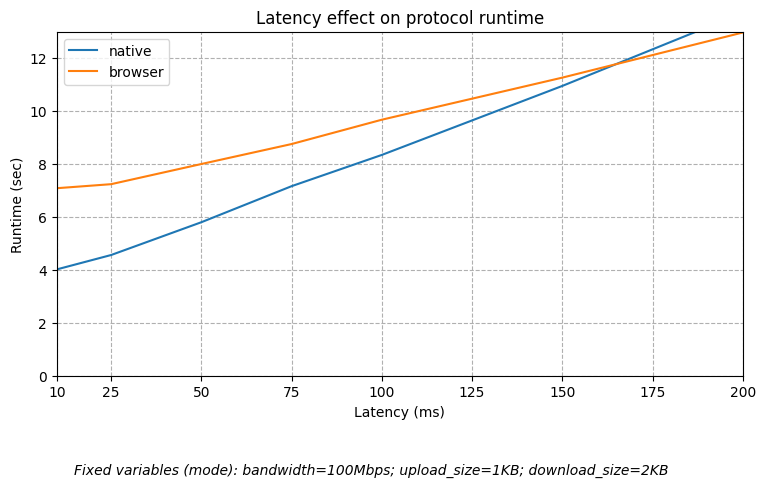

In [43]:
plt.style.use("default")

fig, ax = plt.subplots(figsize=(8, 5))

df1 = pd.read_csv("tlsn-experiments/tlsn-latency-native.csv", header=0).dropna(subset=["group"])
df2 = pd.read_csv("tlsn-experiments/tlsn-latency-browser.csv", header=0).dropna(subset=["group"])

agg1 = df1.groupby("latency")["time_total"].mean().reset_index().sort_values("latency")
agg2 = df2.groupby("latency")["time_total"].mean().reset_index().sort_values("latency")

ax.plot(agg1["latency"], agg1["time_total"] / 1000.0, label="native")
ax.plot(agg2["latency"], agg2["time_total"] / 1000.0, label="browser")

ax.set_ylim(0, 13)
ax.set_xlim(10, 200)
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Runtime (sec)")
ax.set_title("Latency effect on protocol runtime")
ax.legend(loc="upper left")
ax.set_xticks([10] + list(range(25, 201, 25)))
ax.grid(True, linestyle="--")

fixed_note = build_fixed_note(df1, df2, varying_cols={"latency"})
add_fixed_note(fig, fixed_note)

plt.tight_layout(rect=[0.03, 0.12, 1, 1])
plt.savefig("latency.svg", bbox_inches="tight")
plt.show()


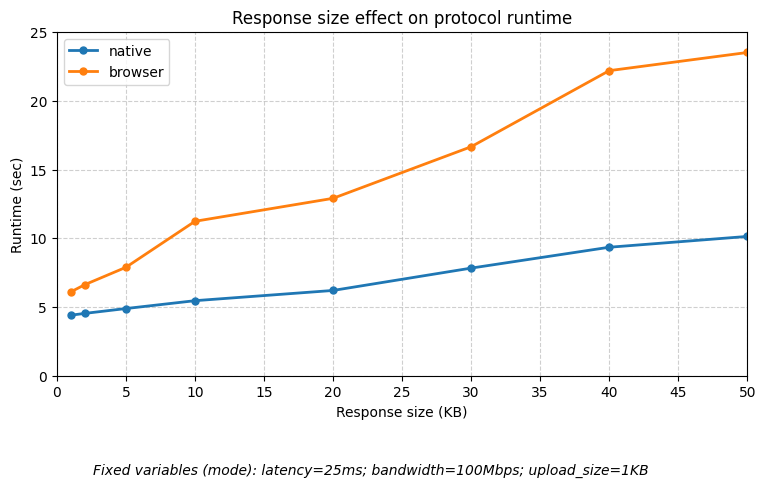

In [44]:
plt.style.use("default")

fig, ax = plt.subplots(figsize=(8, 5))

df1 = pd.read_csv("tlsn-experiments/tlsn-download-native.csv", header=0).dropna(subset=["group"])
df2 = pd.read_csv("tlsn-experiments/tlsn-download-browser.csv", header=0).dropna(subset=["group"])

agg1 = df1.groupby("download_size")["time_total"].mean().reset_index().sort_values("download_size")
agg2 = df2.groupby("download_size")["time_total"].mean().reset_index().sort_values("download_size")

x1 = agg1["download_size"] / 1024.0
x2 = agg2["download_size"] / 1024.0
y1 = agg1["time_total"] / 1000.0
y2 = agg2["time_total"] / 1000.0

ax.plot(x1, y1, marker="o", linewidth=2, markersize=5, label="native")
ax.plot(x2, y2, marker="o", linewidth=2, markersize=5, label="browser")

x_max = int(np.ceil(max(x1.max(), x2.max()) / 5.0) * 5)
ax.set_xlim(0, x_max)
ax.set_xticks(np.arange(0, x_max + 5, 5))

# tighten y-range to improve readability
y_max = max(y1.max(), y2.max())
y_top = int(np.ceil((y_max + 1.0) / 5.0) * 5)
y_step = 2 if y_top <= 24 else 5
ax.set_ylim(0, y_top)
ax.set_yticks(np.arange(0, y_top + y_step, y_step))

ax.set_xlabel("Response size (KB)")
ax.set_ylabel("Runtime (sec)")
ax.set_title("Response size effect on protocol runtime")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.6)

fixed_note = build_fixed_note(df1, df2, varying_cols={"download_size"})
add_fixed_note(fig, fixed_note)

plt.tight_layout(rect=[0.03, 0.12, 1, 1])
plt.savefig("response_size.svg", bbox_inches="tight")
plt.show()


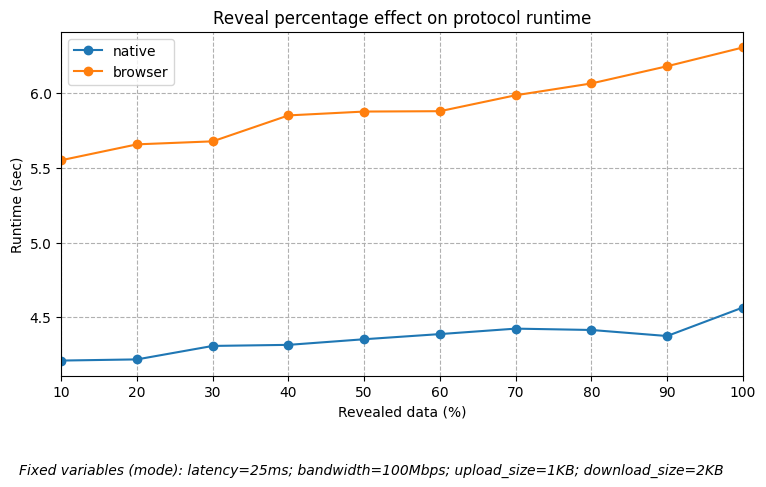

In [45]:
plt.style.use("default")

fig, ax = plt.subplots(figsize=(8, 5))

df1 = pd.read_csv("tlsn-experiments/tlsn-proof-reveal-native.csv", header=0)
df2 = pd.read_csv("tlsn-experiments/tlsn-proof-reveal-browser.csv", header=0)

merged = pd.concat([df1, df2], ignore_index=True)
lat_fixed = merged["latency"].dropna().mode().iloc[0]
bw_fixed = merged["bandwidth"].dropna().mode().iloc[0]
up_fixed = merged["upload_size"].dropna().mode().iloc[0]
down_fixed = merged["download_size"].dropna().mode().iloc[0]

df1 = df1[(df1["latency"] == lat_fixed) & (df1["bandwidth"] == bw_fixed) & (df1["upload_size"] == up_fixed) & (df1["download_size"] == down_fixed)].copy()
df2 = df2[(df2["latency"] == lat_fixed) & (df2["bandwidth"] == bw_fixed) & (df2["upload_size"] == up_fixed) & (df2["download_size"] == down_fixed)].copy()

df1["reveal_percent"] = pd.to_numeric(df1["name"].astype(str).str.extract(r"reveal_(\\d+)pct")[0], errors="coerce")
df2["reveal_percent"] = pd.to_numeric(df2["name"].astype(str).str.extract(r"reveal_(\\d+)pct")[0], errors="coerce")
df1["reveal_percent"] = df1["reveal_percent"].fillna(df1["reveal_recv_percent_actual"].round(0)).astype(int)
df2["reveal_percent"] = df2["reveal_percent"].fillna(df2["reveal_recv_percent_actual"].round(0)).astype(int)

agg1 = df1.groupby("reveal_percent")["time_total"].mean().reset_index().sort_values("reveal_percent")
agg2 = df2.groupby("reveal_percent")["time_total"].mean().reset_index().sort_values("reveal_percent")

x1 = agg1["reveal_percent"]
x2 = agg2["reveal_percent"]
y1 = agg1["time_total"] / 1000.0
y2 = agg2["time_total"] / 1000.0

ax.plot(x1, y1, marker="o", label="native")
ax.plot(x2, y2, marker="o", label="browser")

ax.set_xlim(10, 100)
ax.set_xticks(np.arange(10, 101, 10))
ax.set_xlabel("Revealed data (%)")
ax.set_ylabel("Runtime (sec)")
ax.set_title("Reveal percentage effect on protocol runtime")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--")

fixed_note = build_fixed_note(df1, df2, varying_cols={"reveal_percent", "reveal_recv_percent_actual", "name"})
add_fixed_note(fig, fixed_note)

plt.tight_layout(rect=[0.03, 0.12, 1, 1])
plt.savefig("proof_reveal.svg", bbox_inches="tight")
plt.show()


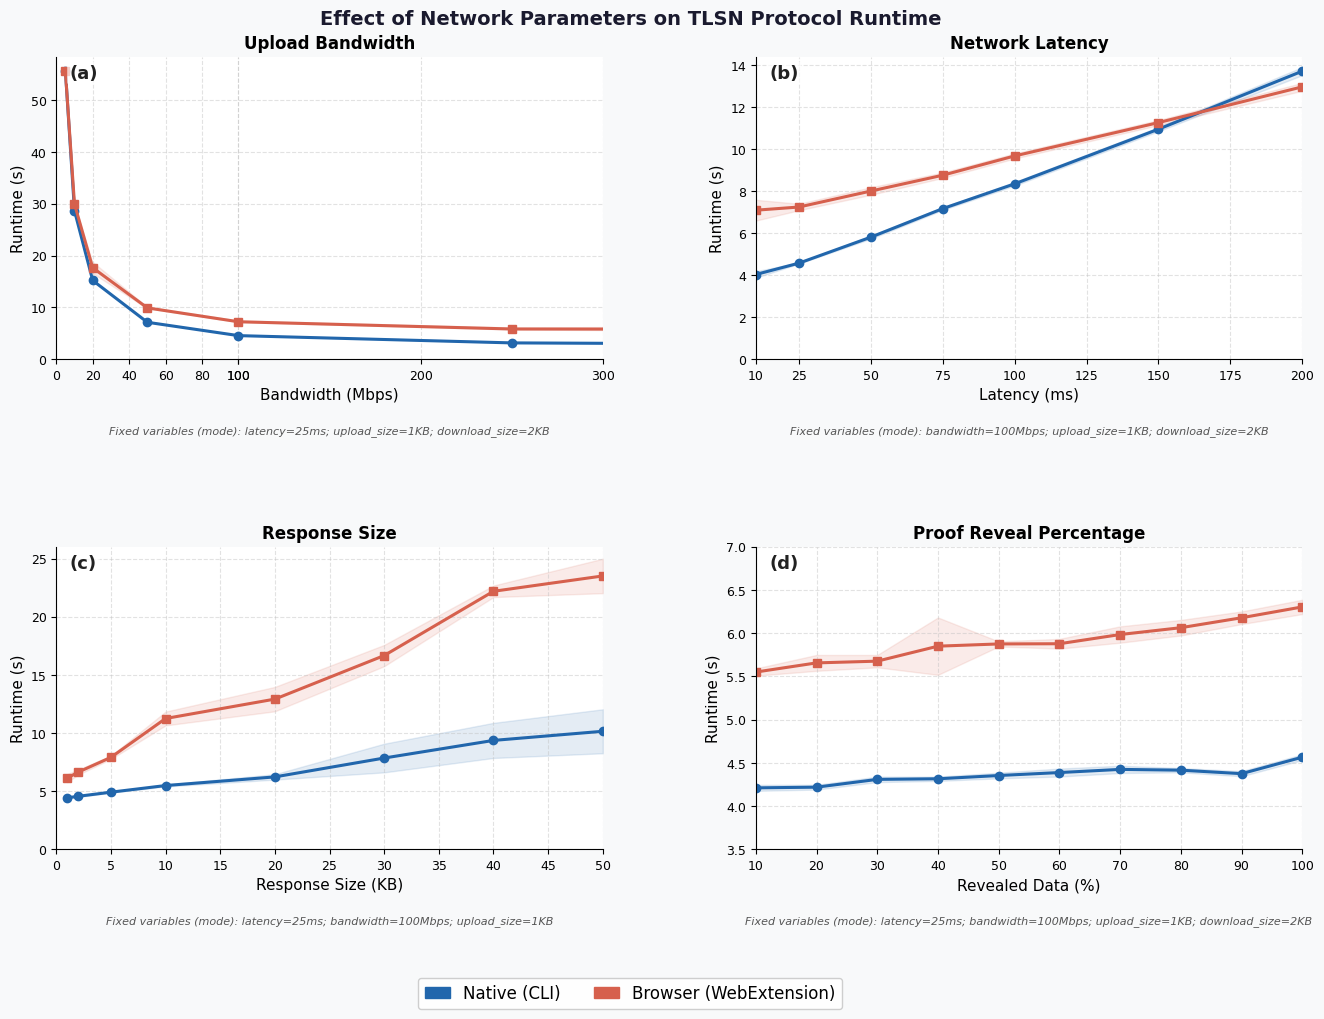

Saved  →  combined.svg  |  combined.pdf


In [46]:

# ── Combined 2×2 publication figure ───────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

C_NATIVE  = "#2166ac"
C_BROWSER = "#d6604d"
LW, MS = 2.2, 6

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.linestyle":     "--",
    "grid.alpha":         0.45,
    "grid.color":         "#c0c0c0",
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10.5))
fig.patch.set_facecolor("#f8f9fa")
for ax in axes.flat:
    ax.set_facecolor("#ffffff")

def add_ax_note(ax, df_list, varying_cols):
    """Place fixed-variable summary just below the subplot x-axis label."""
    note = build_fixed_note(df_list[0], df_list[1], varying_cols)
    ax.text(0.5, -0.22, note, transform=ax.transAxes,
            ha="center", va="top", fontsize=8, style="italic",
            color="#555555", clip_on=False)

# ── (a) Bandwidth ──────────────────────────────────────────────────
ax = axes[0, 0]
df1 = pd.read_csv("tlsn-experiments/tlsn-bandwidth-native.csv").dropna(subset=["group"])
df2 = pd.read_csv("tlsn-experiments/tlsn-bandwidth-browser.csv").dropna(subset=["group"])
a1 = df1.groupby("bandwidth")["time_total"].agg(["mean","std"]).reset_index().sort_values("bandwidth")
a2 = df2.groupby("bandwidth")["time_total"].agg(["mean","std"]).reset_index().sort_values("bandwidth")
x1, y1, e1 = a1["bandwidth"], a1["mean"]/1000, a1["std"]/1000
x2, y2, e2 = a2["bandwidth"], a2["mean"]/1000, a2["std"]/1000
ax.fill_between(x1, y1-e1, y1+e1, color=C_NATIVE,  alpha=0.12)
ax.fill_between(x2, y2-e2, y2+e2, color=C_BROWSER, alpha=0.12)
ax.plot(x1, y1, color=C_NATIVE,  marker="o", lw=LW, ms=MS, label="Native")
ax.plot(x2, y2, color=C_BROWSER, marker="s", lw=LW, ms=MS, label="Browser")
ax.set_xlim(0, 300); ax.set_ylim(bottom=0)
ax.set_xticks(list(range(0,120,20)) + list(range(100,400,100)))
ax.set_xlabel("Bandwidth (Mbps)"); ax.set_ylabel("Runtime (s)")
ax.set_title("Upload Bandwidth")
add_ax_note(ax, [df1, df2], {"bandwidth"})

# ── (b) Latency ────────────────────────────────────────────────────
ax = axes[0, 1]
df1 = pd.read_csv("tlsn-experiments/tlsn-latency-native.csv").dropna(subset=["group"])
df2 = pd.read_csv("tlsn-experiments/tlsn-latency-browser.csv").dropna(subset=["group"])
a1 = df1.groupby("latency")["time_total"].agg(["mean","std"]).reset_index().sort_values("latency")
a2 = df2.groupby("latency")["time_total"].agg(["mean","std"]).reset_index().sort_values("latency")
x1, y1, e1 = a1["latency"], a1["mean"]/1000, a1["std"]/1000
x2, y2, e2 = a2["latency"], a2["mean"]/1000, a2["std"]/1000
ax.fill_between(x1, y1-e1, y1+e1, color=C_NATIVE,  alpha=0.12)
ax.fill_between(x2, y2-e2, y2+e2, color=C_BROWSER, alpha=0.12)
ax.plot(x1, y1, color=C_NATIVE,  marker="o", lw=LW, ms=MS)
ax.plot(x2, y2, color=C_BROWSER, marker="s", lw=LW, ms=MS)
ax.set_xlim(10, 200); ax.set_ylim(bottom=0)
ax.set_xticks([10] + list(range(25, 201, 25)))
ax.set_xlabel("Latency (ms)"); ax.set_ylabel("Runtime (s)")
ax.set_title("Network Latency")
add_ax_note(ax, [df1, df2], {"latency"})

# ── (c) Response size ──────────────────────────────────────────────
ax = axes[1, 0]
df1 = pd.read_csv("tlsn-experiments/tlsn-download-native.csv").dropna(subset=["group"])
df2 = pd.read_csv("tlsn-experiments/tlsn-download-browser.csv").dropna(subset=["group"])
a1 = df1.groupby("download_size")["time_total"].agg(["mean","std"]).reset_index().sort_values("download_size")
a2 = df2.groupby("download_size")["time_total"].agg(["mean","std"]).reset_index().sort_values("download_size")
x1, y1, e1 = a1["download_size"]/1024, a1["mean"]/1000, a1["std"]/1000
x2, y2, e2 = a2["download_size"]/1024, a2["mean"]/1000, a2["std"]/1000
ax.fill_between(x1, y1-e1, y1+e1, color=C_NATIVE,  alpha=0.12)
ax.fill_between(x2, y2-e2, y2+e2, color=C_BROWSER, alpha=0.12)
ax.plot(x1, y1, color=C_NATIVE,  marker="o", lw=LW, ms=MS)
ax.plot(x2, y2, color=C_BROWSER, marker="s", lw=LW, ms=MS)
x_max = int(np.ceil(max(x1.max(), x2.max()) / 5) * 5)
ax.set_xlim(0, x_max); ax.set_xticks(np.arange(0, x_max+5, 5))
ax.set_ylim(bottom=0)
ax.set_xlabel("Response Size (KB)"); ax.set_ylabel("Runtime (s)")
ax.set_title("Response Size")
add_ax_note(ax, [df1, df2], {"download_size"})

# ── (d) Proof reveal percentage  (y zoomed: 3.5 – 7 s) ────────────
ax = axes[1, 1]
df1 = pd.read_csv("tlsn-experiments/tlsn-proof-reveal-native.csv")
df2 = pd.read_csv("tlsn-experiments/tlsn-proof-reveal-browser.csv")
merged_all = pd.concat([df1, df2], ignore_index=True)
lat_f = merged_all["latency"].dropna().mode().iloc[0]
bw_f  = merged_all["bandwidth"].dropna().mode().iloc[0]
up_f  = merged_all["upload_size"].dropna().mode().iloc[0]
dn_f  = merged_all["download_size"].dropna().mode().iloc[0]

def prep_reveal(df):
    df = df[(df["latency"]==lat_f) & (df["bandwidth"]==bw_f) &
            (df["upload_size"]==up_f) & (df["download_size"]==dn_f)].copy()
    df["reveal_pct"] = pd.to_numeric(
        df["name"].astype(str).str.extract(r"reveal_(\d+)pct")[0], errors="coerce")
    df["reveal_pct"] = df["reveal_pct"].fillna(
        df["reveal_recv_percent_actual"].round(0)).astype(int)
    return df.groupby("reveal_pct")["time_total"].agg(["mean","std"]).reset_index().sort_values("reveal_pct")

a1 = prep_reveal(df1); a2 = prep_reveal(df2)
df1_f = df1[(df1["latency"]==lat_f)&(df1["bandwidth"]==bw_f)&(df1["upload_size"]==up_f)&(df1["download_size"]==dn_f)].copy()
df2_f = df2[(df2["latency"]==lat_f)&(df2["bandwidth"]==bw_f)&(df2["upload_size"]==up_f)&(df2["download_size"]==dn_f)].copy()
x1, y1, e1 = a1["reveal_pct"], a1["mean"]/1000, a1["std"]/1000
x2, y2, e2 = a2["reveal_pct"], a2["mean"]/1000, a2["std"]/1000
ax.fill_between(x1, y1-e1, y1+e1, color=C_NATIVE,  alpha=0.12)
ax.fill_between(x2, y2-e2, y2+e2, color=C_BROWSER, alpha=0.12)
ax.plot(x1, y1, color=C_NATIVE,  marker="o", lw=LW, ms=MS)
ax.plot(x2, y2, color=C_BROWSER, marker="s", lw=LW, ms=MS)
ax.set_xlim(10, 100); ax.set_xticks(np.arange(10, 101, 10))
ax.set_ylim(3.5, 7.0)
ax.set_xlabel("Revealed Data (%)"); ax.set_ylabel("Runtime (s)")
ax.set_title("Proof Reveal Percentage")
add_ax_note(ax, [df1_f, df2_f], {"reveal_pct", "reveal_recv_percent_actual", "name"})

# ── Panel labels (a)–(d) ───────────────────────────────────────────
for idx, ax in enumerate(axes.flat):
    ax.text(0.025, 0.975, f"({chr(ord('a')+idx)})",
            transform=ax.transAxes, fontsize=13, fontweight="bold",
            va="top", ha="left", color="#222222",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

# ── Shared legend & overall title ─────────────────────────────────
p_native  = mpatches.Patch(color=C_NATIVE,  label="Native (CLI)")
p_browser = mpatches.Patch(color=C_BROWSER, label="Browser (WebExtension)")
fig.legend(handles=[p_native, p_browser],
           loc="lower center", ncol=2, frameon=True, framealpha=0.95,
           edgecolor="#cccccc", fontsize=12, handlelength=1.5,
           bbox_to_anchor=(0.5, 0.02))

fig.suptitle("Effect of Network Parameters on TLSN Protocol Runtime",
             fontsize=14, fontweight="bold", color="#1a1a2e")

# bottom=0.18: lower portion is split as — note text (top) | gap | legend (bottom)
fig.subplots_adjust(left=0.09, right=0.98, top=0.935,
                    bottom=0.18, hspace=0.62, wspace=0.28)

plt.savefig("combined.svg", bbox_inches="tight")
plt.savefig("combined.pdf", bbox_inches="tight")
plt.show()
print("Saved  →  combined.svg  |  combined.pdf")


In [47]:
# ─── Statistical Summary: Alipay vs Wise Proof ① / ② (all conditions) ─────────

import pandas as pd
import numpy as np
from pathlib import Path

BASE  = Path("wise_alipay")
C_ALI = [("ideal", 2), ("broadband", 50), ("crossregion", 150), ("4g", 80)]
C_WIS = [("ideal", 2), ("broadband", 50), ("crossregion", 150), ("4g", 80)]

def load(fname):
    df = pd.read_csv(BASE / fname)
    return df[
        (df["error"].astype(str).str.lower() == "false") &
        (df["cold_start"].astype(str).str.lower() == "false")
    ]

def make_row(service, condition, rtt, df):
    tot    = df["totalProtocolMs"] / 1000
    conn   = df["connectionMs"]    / 1000
    req    = df["requestMs"]       / 1000
    pg     = df["proofGenerationMs"]
    reveal = df["revealRatioPct"]
    return {
        "Service":       service,
        "Condition":     f"{condition} ({rtt}ms RTT)",
        "N":             len(df),
        "Median (s)":    f"{tot.median():.2f}",
        "P95 (s)":       f"{tot.quantile(0.95):.2f}",
        "Conn (s)":      f"{conn.mean():.2f}",
        "Conn %":        f"{conn.mean()/tot.mean()*100:.0f}%",
        "Req (s)":       f"{req.mean():.2f}",
        "ProofGen (ms)": f"{pg.mean():.0f}",
        "Reveal % (max)": f"{reveal.max():.1f}%",
    }

rows = []

for cname, rtt in C_ALI:
    df = load(f"alipay_{cname}.csv")
    rows.append(make_row("Alipay", cname.capitalize(), rtt, df))

for pi, label in [(0, "Wise Proof ①"), (1, "Wise Proof ②")]:
    for cname, rtt in C_WIS:
        raw = load(f"wise_{cname}.csv")
        d   = raw[raw["prove_index"] == pi]
        rows.append(make_row(label, cname.capitalize(), rtt, d))

out = pd.DataFrame(rows).set_index(["Service", "Condition"])
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
print("Per-proof comparison  ·  Alipay = 1 proof/session  ·  Wise Proof① / Proof② shown separately")
print("=" * 110)
print(out.to_string())

Per-proof comparison  ·  Alipay = 1 proof/session  ·  Wise Proof① / Proof② shown separately
                                       N Median (s) P95 (s) Conn (s) Conn % Req (s) ProofGen (ms) Reveal % (max)
Service      Condition                                                                                          
Alipay       Ideal (2ms RTT)          19       5.94    6.28     3.16    53%    1.44           324          11.8%
             Broadband (50ms RTT)     19      17.44   18.14    11.54    72%    2.87           537          11.8%
             Crossregion (150ms RTT)  19      24.98   41.15    19.90    70%    6.16          1485          11.7%
             4g (80ms RTT)            19      37.38   39.67    32.40    85%    3.77           833          11.7%
Wise Proof ① Ideal (2ms RTT)          19       9.74   10.60     6.54    67%    2.17            37           2.4%
             Broadband (50ms RTT)     19      21.02   27.67    17.25    74%    4.82           171           2.4%
    

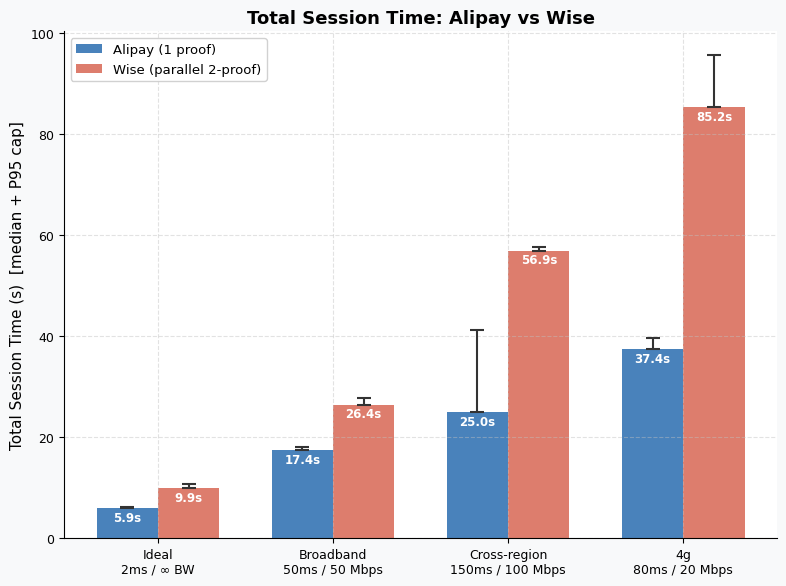

Saved → wise_alipay_total_time.svg


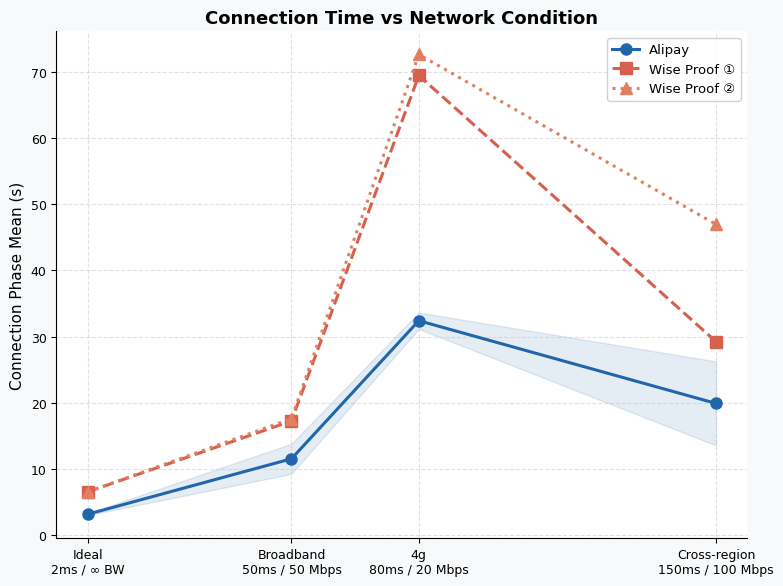

Saved → wise_alipay_connection.svg


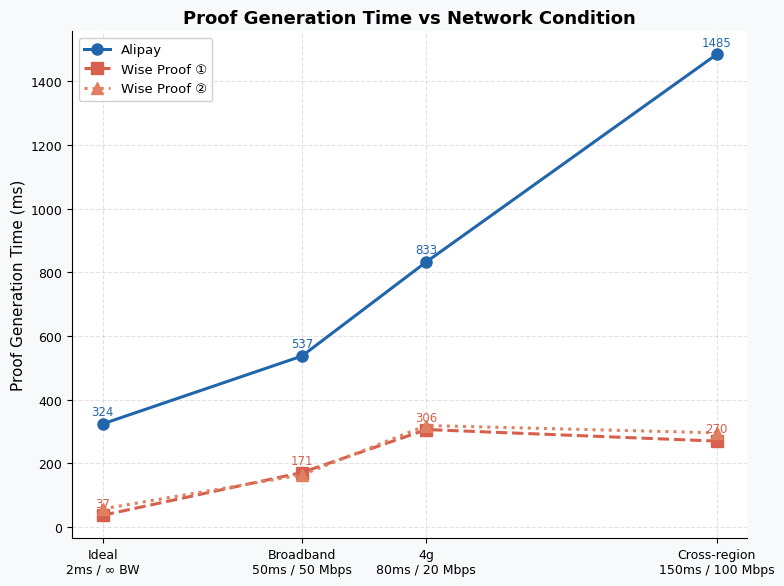

Saved → wise_alipay_proofgen.svg


In [48]:
# ─── Alipay vs Wise: Cross-Network Performance Comparison ────────────────────

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

BASE = Path("wise_alipay")

# Display order: ideal → broadband → cross-region → 4G
CONDS = [
    ("ideal",       2,   "∞ BW"),
    ("broadband",   50,  "50 Mbps"),
    ("crossregion", 150, "100 Mbps"),
    ("4g",          80,  "20 Mbps"),
]
# RTT-sorted variant for line charts (monotonic x-axis)
CONDS_RTT = sorted(CONDS, key=lambda c: c[1])

C_ALIPAY = "#2166ac"
C_WISE   = "#d6604d"
PHASES   = ["connectionMs", "requestMs", "proofGenerationMs", "verificationMs"]

def load(fname):
    df = pd.read_csv(BASE / fname)
    return df[
        (df["error"].astype(str).str.lower() == "false") &
        (df["cold_start"].astype(str).str.lower() == "false")
    ]

def wise_session(df):
    p0 = set(df[df["prove_index"] == 0]["run"])
    p1 = set(df[df["prove_index"] == 1]["run"])
    d  = df[df["run"].isin(p0 & p1)]
    # proofs run in parallel → wall-clock = max(p0, p1) per run
    return d.groupby("run")[PHASES + ["totalProtocolMs"]].max().reset_index()

def wise_phase_mean(cname, phase):
    df = load(f"wise_{cname}.csv")
    return (df[df["prove_index"] == 0][phase].mean() / 1000,
            df[df["prove_index"] == 1][phase].mean() / 1000)

def cname_label(k):
    return "Cross-region" if k == "crossregion" else k.capitalize()

ali  = {k: load(f"alipay_{k}.csv")            for k, _, __ in CONDS}
wise = {k: wise_session(load(f"wise_{k}.csv")) for k, _, __ in CONDS}

RC = {
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.linestyle": "--", "grid.alpha": 0.45, "grid.color": "#c0c0c0",
}

# Shared x-tick labels for line charts (RTT-sorted)
rtt_tick_labels = [f"{cname_label(k)}\n{rtt}ms / {bw}" for k, rtt, bw in CONDS_RTT]
rtts = [rtt for _, rtt, __ in CONDS_RTT]

# ════════════════════════════════════════════════════════════════════════════
# Figure (a) — Total Session Time
# ════════════════════════════════════════════════════════════════════════════
plt.rcParams.update(RC)
fig_a, ax = plt.subplots(figsize=(8, 6))
fig_a.patch.set_facecolor("#f8f9fa")
ax.set_facecolor("#ffffff")

bar_labels = [f"{cname_label(k)}\n{rtt}ms / {bw}" for k, rtt, bw in CONDS]
ali_med  = [ali[k]["totalProtocolMs"].median()       / 1000 for k, _, __ in CONDS]
wise_med = [wise[k]["totalProtocolMs"].median()       / 1000 for k, _, __ in CONDS]
ali_p95  = [ali[k]["totalProtocolMs"].quantile(0.95)  / 1000 for k, _, __ in CONDS]
wise_p95 = [wise[k]["totalProtocolMs"].quantile(0.95) / 1000 for k, _, __ in CONDS]

x = np.arange(4)
w = 0.35
b1 = ax.bar(x - w/2, ali_med,  w, color=C_ALIPAY, alpha=0.82, label="Alipay (1 proof)")
b2 = ax.bar(x + w/2, wise_med, w, color=C_WISE,   alpha=0.82, label="Wise (parallel 2-proof)")
ax.errorbar(x - w/2, ali_med,
            yerr=[np.zeros(4), np.array(ali_p95) - np.array(ali_med)],
            fmt="none", color="#333333", capsize=5, capthick=1.5, elinewidth=1.5)
ax.errorbar(x + w/2, wise_med,
            yerr=[np.zeros(4), np.array(wise_p95) - np.array(wise_med)],
            fmt="none", color="#333333", capsize=5, capthick=1.5, elinewidth=1.5)
for bar, val in zip(b1, ali_med):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.5,
            f"{val:.1f}s", ha="center", va="top", fontsize=8.5,
            color="white", fontweight="bold")
for bar, val in zip(b2, wise_med):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.5,
            f"{val:.1f}s", ha="center", va="top", fontsize=8.5,
            color="white", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(bar_labels, fontsize=9)
ax.set_ylabel("Total Session Time (s)  [median + P95 cap]")
ax.set_title("Total Session Time: Alipay vs Wise")
ax.legend(fontsize=9.5, framealpha=0.9)
plt.tight_layout()
fig_a.savefig("wise_alipay_total_time.svg", bbox_inches="tight")
plt.show()
print("Saved → wise_alipay_total_time.svg")

# ════════════════════════════════════════════════════════════════════════════
# Figure (b) — Connection Time vs Network Condition
# ════════════════════════════════════════════════════════════════════════════
plt.rcParams.update(RC)
fig_b, ax = plt.subplots(figsize=(8, 6))
fig_b.patch.set_facecolor("#f8f9fa")
ax.set_facecolor("#ffffff")

ali_conn = [ali[k]["connectionMs"].mean() / 1000 for k, _, __ in CONDS_RTT]
ali_cs   = [ali[k]["connectionMs"].std()  / 1000 for k, _, __ in CONDS_RTT]
wp0_conn = [wise_phase_mean(k, "connectionMs")[0] for k, _, __ in CONDS_RTT]
wp1_conn = [wise_phase_mean(k, "connectionMs")[1] for k, _, __ in CONDS_RTT]

ax.fill_between(rtts, [v - s for v, s in zip(ali_conn, ali_cs)],
                [v + s for v, s in zip(ali_conn, ali_cs)],
                alpha=0.12, color=C_ALIPAY)
ax.plot(rtts, ali_conn,  "o-",  color=C_ALIPAY,  lw=2.2, ms=8, label="Alipay")
ax.plot(rtts, wp0_conn,  "s--", color=C_WISE,    lw=2.2, ms=8, label="Wise Proof ①")
ax.plot(rtts, wp1_conn,  "^:",  color="#e08060",  lw=2.2, ms=8, label="Wise Proof ②")

ax.set_xticks(rtts)
ax.set_xticklabels(rtt_tick_labels, fontsize=9)
ax.set_xlabel("")
ax.set_ylabel("Connection Phase Mean (s)")
ax.set_title("Connection Time vs Network Condition")
ax.legend(fontsize=9.5, framealpha=0.9)
plt.tight_layout()
fig_b.savefig("wise_alipay_connection.svg", bbox_inches="tight")
plt.show()
print("Saved → wise_alipay_connection.svg")

# ════════════════════════════════════════════════════════════════════════════
# Figure (c) — Proof Generation Time vs Network Condition
# ════════════════════════════════════════════════════════════════════════════
plt.rcParams.update(RC)
fig_c, ax = plt.subplots(figsize=(8, 6))
fig_c.patch.set_facecolor("#f8f9fa")
ax.set_facecolor("#ffffff")

ali_pg  = [ali[k]["proofGenerationMs"].mean()              for k, _, __ in CONDS_RTT]
wp0_pg  = [wise_phase_mean(k, "proofGenerationMs")[0]*1000 for k, _, __ in CONDS_RTT]
wp1_pg  = [wise_phase_mean(k, "proofGenerationMs")[1]*1000 for k, _, __ in CONDS_RTT]

ax.plot(rtts, ali_pg,  "o-",  color=C_ALIPAY,  lw=2.2, ms=8, label="Alipay")
ax.plot(rtts, wp0_pg,  "s--", color=C_WISE,    lw=2.2, ms=8, label="Wise Proof ①")
ax.plot(rtts, wp1_pg,  "^:",  color="#e08060",  lw=2.2, ms=8, label="Wise Proof ②")
for xs, ys, color in [(rtts, ali_pg, C_ALIPAY), (rtts, wp0_pg, C_WISE)]:
    for x_pt, y_pt in zip(xs, ys):
        ax.text(x_pt, y_pt + 18, f"{y_pt:.0f}", ha="center", va="bottom",
                fontsize=8.5, color=color)

ax.set_xticks(rtts)
ax.set_xticklabels(rtt_tick_labels, fontsize=9)
ax.set_xlabel("")
ax.set_ylabel("Proof Generation Time (ms)")
ax.set_title("Proof Generation Time vs Network Condition")
ax.legend(fontsize=9.5, framealpha=0.9)
plt.tight_layout()
fig_c.savefig("wise_alipay_proofgen.svg", bbox_inches="tight")
plt.show()
print("Saved → wise_alipay_proofgen.svg")